In [1]:
from data_augmenter import DataAugmenter

In [2]:
import os
import cv2
import random
import matplotlib.pyplot as plt
from typing import List

def visualize_augmented_grid(target_dir: str, n_images: int = 6, cols: int = 3):
    """
    Displays a grid of augmented images with their bounding boxes 
    directly in a Jupyter Notebook.
    
    :param target_dir: Path to the directory with augmented .jpg and .txt files.
    :param n_images: Total number of random images to display.
    :param cols: Number of columns in the grid.
    """
    valid_extensions = ('.jpg', '.jpeg', '.png')
    images = [f for f in os.listdir(target_dir) if f.lower().endswith(valid_extensions)]
    
    if not images:
        print(f"No images found in {target_dir}")
        return

    # Select random samples
    sample_images = random.sample(images, min(n_images, len(images)))
    rows = (len(sample_images) + cols - 1) // cols
    
    plt.figure(figsize=(20, 10 * rows))
    
    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(target_dir, img_name)
        label_path = os.path.join(target_dir, os.path.splitext(img_name)[0] + ".txt")
        
        # Load and convert BGR to RGB for Matplotlib
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape
        
        # Draw labels if they exist
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.split()
                    if len(parts) < 5: continue
                    
                    x_c, y_c, wb, hb = map(float, parts[1:])
                    # Scaled coordinates
                    x1 = int((x_c - wb/2) * w)
                    y1 = int((y_c - hb/2) * h)
                    x2 = int((x_c + wb/2) * w)
                    y2 = int((y_c + hb/2) * h)
                    
                    # Draw a thin bounding box
                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 3)

        # Plot in the grid
        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.title(f"{img_name}\n({w}x{h})", fontsize=12)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

In [3]:
data_augmenter = DataAugmenter('../../data', 'original_img', 'original_img_annotations', 'ag_img')
data_augmenter.run_batch(10)

/home/felipe/plain_concept/electronic_symbol_detection/src/data_management/data_augmenter.py:45: UserWarning: Argument(s) 'std_dev' are not valid for transform GaussNoise
  A.GaussNoise(std_dev=(2.0, 4.5), p=0.3),


Found 16 pairs. Starting augmentation...
Process complete. Check ../../data/ag_img


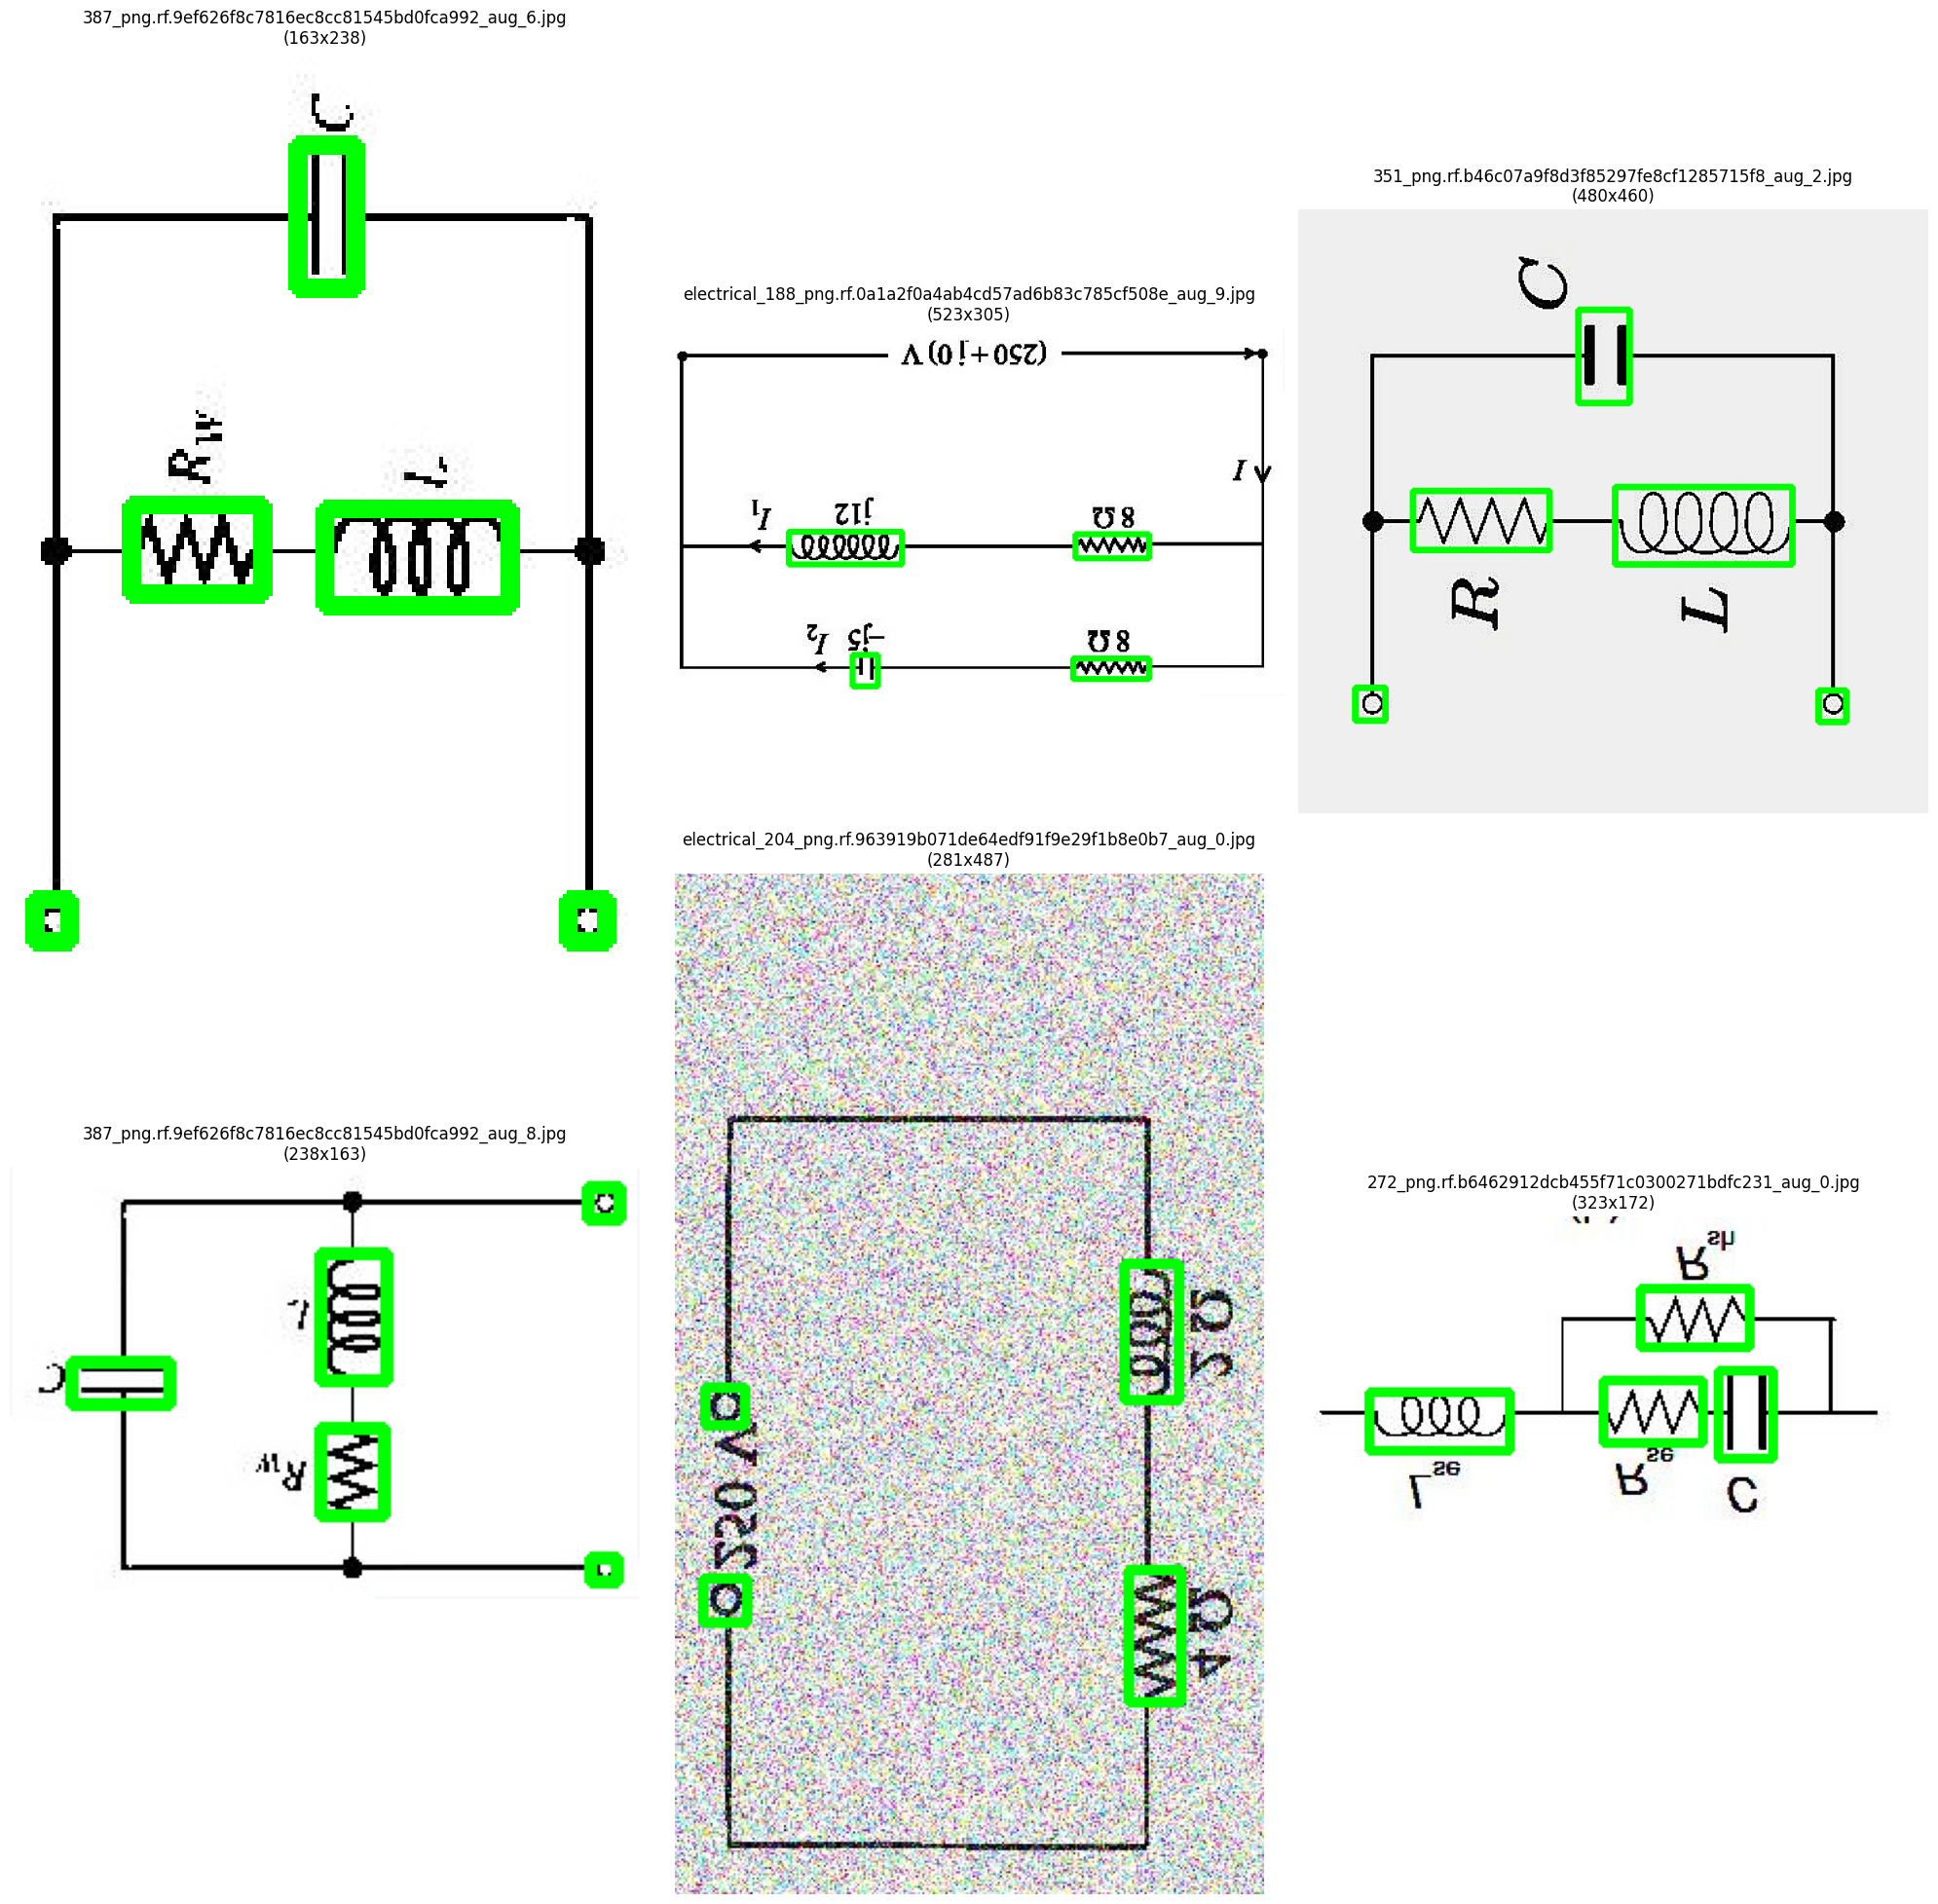

In [4]:
visualize_augmented_grid('../../data/ag_img')